# Grouping Comparison Experiment

Compares five alert-grouping methods (fixed window, time-delta, CSCAS-style,
AlertBERT, DeepCASE) on the held-out test scenarios (`fox`,
`russellmitchell`): alert volume reduction, group size distribution, group
purity, and (DeepCASE only) the fraction of alerts rejected outright rather
than grouped (`ungroupable_fraction`).

Each method's sweep now runs as its own standalone script
(`src/thesis/baselines/grouping/*.py`) rather than inline in this notebook
-- this notebook only loads their `results/*.json` (+ `*_sizes.npz`)
artifacts and plots them. See `run_grouping.sh` in that directory to run
every script overnight; the `GROUPING_DEVICE` env var selects `mps`/`cuda`/
`cpu` (default: auto-detect) for the two torch-based methods.

**Run the scripts first** to generate the artifacts this notebook reads:
```
cd src/thesis/baselines/grouping
python fixed_window.py
python time_delta.py
python cscas_grouping.py
python cscas_grouping_sensitivity.py
python deepcase_sweep.py
```
`alertbert_sweep.py` needs the separate `thesis-alertbert` conda env
(`alertbert.models` hard-imports `graph_tool`, not part of this project's
plain `venv/`):
```
conda activate thesis-alertbert
KMP_DUPLICATE_LIB_OK=TRUE python alertbert_sweep.py
```
This notebook itself only needs the plain venv -- it never imports
`thesis.grouping`/`torch`/`alertbert`/`deepcase`.


## 1. Imports

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thesis.baselines.grouping._results import (
    load_grouping_results,
    load_group_size_arrays,
)


## 2. Settings

Edit and re-run -- nothing past this cell needs to change.


In [2]:
# The 5 methods that feed the shared cross-method comparison (each has a
# results/{name}.json + results/{name}_sizes.npz, written by the
# like-named script in src/thesis/baselines/grouping/).
GROUPING_RESULT_NAMES = ["fixed_window", "time_delta", "cscas_grouping", "alertbert", "deepcase"]

# CSCAS's authors' own validated production settings -- must match the
# primary config baked into cscas_grouping.py/cscas_grouping_sensitivity.py.
# Only used here for the sensitivity plot's reference lines.
CSCAS_SESSION_LENGTH_SECONDS = 300.0
CSCAS_SESSION_TIMEOUT_SECONDS = 60.0

# Shared across every scenario-aware plot below so "fox" reads as the same
# color/marker everywhere in this notebook.
SCENARIO_COLORS = {"fox": "#4477AA", "russellmitchell": "#EE6677"}
SCENARIO_MARKERS = {"fox": "o", "russellmitchell": "^"}


## 3. Loading

Tolerant of missing artifacts (prints `[skip] ...` and continues) -- run
whichever scripts you have, this notebook plots whatever's available.


In [3]:
results_dfs: dict[str, pd.DataFrame] = {}
size_arrays: dict[tuple, np.ndarray] = {}
for name in GROUPING_RESULT_NAMES:
    try:
        results_dfs[name] = load_grouping_results(name)
        size_arrays.update(load_group_size_arrays(name))
    except FileNotFoundError as e:
        print(f"[skip] {e}")

print(f"Loaded results for: {list(results_dfs.keys())}")

# Derived columns needed by the per-method diagnostic plots below -- moved
# here from what used to be inline sweep cells.
if "time_delta" in results_dfs:
    results_dfs["time_delta"]["delta"] = results_dfs["time_delta"]["param"].astype(float)
if "deepcase" in results_dfs:
    results_dfs["deepcase"]["context_length"] = (
        results_dfs["deepcase"]["param"].str.extract(r"L=(\d+)").astype(int)
    )
    results_dfs["deepcase"]["eps"] = (
        results_dfs["deepcase"]["param"].str.extract(r"eps=([\d.]+)").astype(float)
    )
if "alertbert" in results_dfs:
    results_dfs["alertbert"]["delta"] = (
        results_dfs["alertbert"]["param"].str.extract(r"d=([\d.]+)").astype(float)
    )
    results_dfs["alertbert"]["theta"] = (
        results_dfs["alertbert"]["param"].str.extract(r"t=([\d.]+)").astype(float)
    )

all_results_df = (
    pd.concat(results_dfs.values(), ignore_index=True) if results_dfs else pd.DataFrame()
)

try:
    cscas_sensitivity_df = load_grouping_results("cscas_grouping_sensitivity")
except FileNotFoundError as e:
    print(f"[skip] {e}")
    cscas_sensitivity_df = pd.DataFrame()

try:
    manual_review_df = load_grouping_results("deepcase_manual_review")
except FileNotFoundError as e:
    print(f"[skip] {e}")
    manual_review_df = pd.DataFrame()


Loaded results for: ['fixed_window', 'time_delta', 'cscas_grouping', 'alertbert', 'deepcase']


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_22006/2890516554.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(results_dfs.values(), ignore_index=True) if results_dfs else pd.DataFrame()


## 4. Fixed window

Linear sweep (this method's parameter is an absolute group size, not a
gap threshold, so no log-scale sweep here — see the time-delta section
for why that distinction matters).


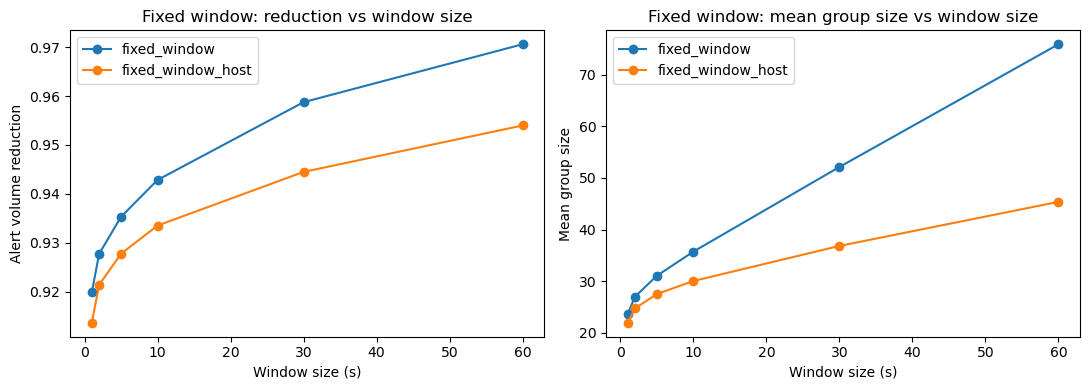

In [4]:
fixed_window_df = results_dfs.get("fixed_window")
if fixed_window_df is None:
    print("[skip] fixed_window not loaded -- run fixed_window.py first")
else:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    for method_name, group in fixed_window_df.groupby("method"):
        agg = group.groupby("param", as_index=False)["reduction"].mean()
        agg["param"] = agg["param"].astype(int)
        agg = agg.sort_values("param")
        ax[0].plot(agg["param"], agg["reduction"], marker="o", label=method_name)

    ax[0].set_xlabel("Window size (s)")
    ax[0].set_ylabel("Alert volume reduction")
    ax[0].set_title("Fixed window: reduction vs window size")
    ax[0].legend()

    for method_name, group in fixed_window_df.groupby("method"):
        agg = group.groupby("param", as_index=False)["group_size_mean"].mean()
        agg["param"] = agg["param"].astype(int)
        agg = agg.sort_values("param")
        ax[1].plot(agg["param"], agg["group_size_mean"], marker="o", label=method_name)

    ax[1].set_xlabel("Window size (s)")
    ax[1].set_ylabel("Mean group size")
    ax[1].set_title("Fixed window: mean group size vs window size")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


## 5. Time-delta

Log-scale sweep matching the original method's own validated evaluation
protocol: `delta = a * 2**i` for `i = -7 ... 13`, `a in {1, 1.5}`. This
range spans sub-second to multi-hour gaps, which matters specifically
because AIT-ADS alerts have whole-second timestamp resolution for many
detectors — a coarser, linear sweep would miss the discontinuity around
delta = 1s entirely.


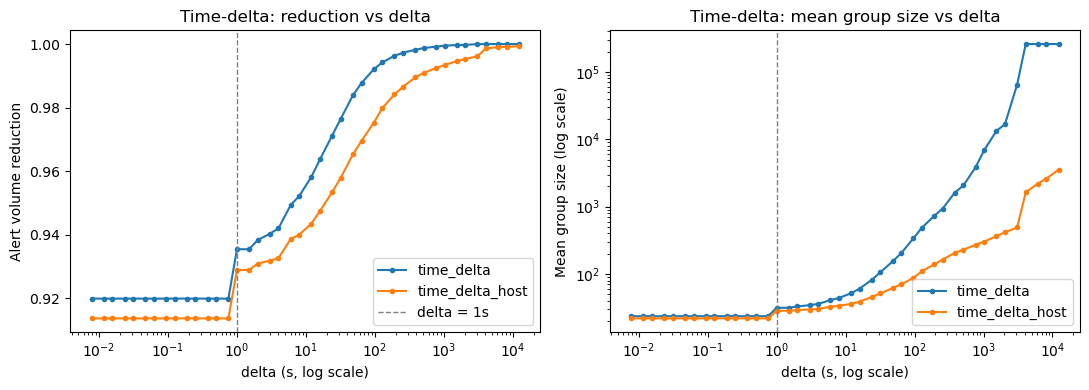

In [5]:
time_delta_df = results_dfs.get("time_delta")
if time_delta_df is None:
    print("[skip] time_delta not loaded -- run time_delta.py first")
else:
    # Per-method diagnostic plot: log-x reduction curve, flags the delta=1s
    # discontinuity described above.
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    for method_name, group in time_delta_df.groupby("method"):
        agg = group.groupby("delta", as_index=False)["reduction"].mean().sort_values("delta")
        ax[0].plot(agg["delta"], agg["reduction"], marker=".", label=method_name)

    ax[0].set_xscale("log")
    ax[0].axvline(1.0, color="grey", linestyle="--", linewidth=1, label="delta = 1s")
    ax[0].set_xlabel("delta (s, log scale)")
    ax[0].set_ylabel("Alert volume reduction")
    ax[0].set_title("Time-delta: reduction vs delta")
    ax[0].legend()

    for method_name, group in time_delta_df.groupby("method"):
        agg = group.groupby("delta", as_index=False)["group_size_mean"].mean().sort_values("delta")
        ax[1].plot(agg["delta"], agg["group_size_mean"], marker=".", label=method_name)

    ax[1].set_xscale("log")
    ax[1].set_yscale("log")
    ax[1].axvline(1.0, color="grey", linestyle="--", linewidth=1)
    ax[1].set_xlabel("delta (s, log scale)")
    ax[1].set_ylabel("Mean group size (log scale)")
    ax[1].set_title("Time-delta: mean group size vs delta")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


## 6. CSCAS grouping

Single fixed configuration — the authors' own validated production
settings (SessionLength=300s, SessionTimeout=60s), not swept.


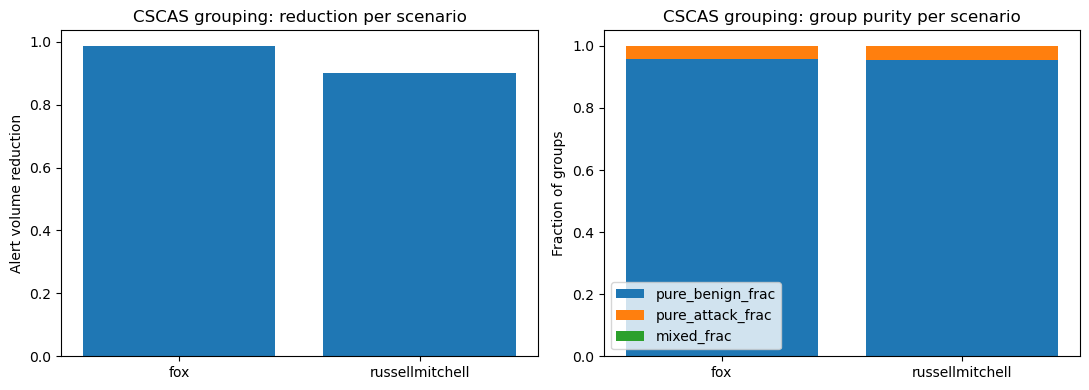

In [6]:
cscas_df = results_dfs.get("cscas_grouping")
if cscas_df is None:
    print("[skip] cscas_grouping not loaded -- run cscas_grouping.py first")
else:
    # Per-method diagnostic plot: reduction and purity per scenario (single config, so bars not curves)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    ax[0].bar(cscas_df["scenario"], cscas_df["reduction"])
    ax[0].set_ylabel("Alert volume reduction")
    ax[0].set_title("CSCAS grouping: reduction per scenario")

    purity_cols = ["pure_benign_frac", "pure_attack_frac", "mixed_frac"]
    bottom = np.zeros(len(cscas_df))
    for col in purity_cols:
        ax[1].bar(cscas_df["scenario"], cscas_df[col], bottom=bottom, label=col)
        bottom += cscas_df[col].values
    ax[1].set_ylabel("Fraction of groups")
    ax[1].set_title("CSCAS grouping: group purity per scenario")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


### 6b. CSCAS sensitivity sweep (secondary)

The run above uses the authors' single validated production configuration
(`SessionLength=300s`, `SessionTimeout=60s`) as CSCAS's primary result --
that's the artifact that feeds the cross-method comparison in section 9.
Those values were tuned by the original authors for Suricata's alert
density specifically, and CSCAS-style grouping has since been generalized
here to all three IDS sources -- so it's a fair question whether 60s/300s
still makes sense once the input population has changed.

This secondary sweep (`cscas_grouping_sensitivity.py`, a separate script
writing a separate artifact) answers that as a **robustness check, not a
search for a better operating point**: it varies each parameter one at a
time rather than a full factorial -- `session_timeout ∈ {30, 60, 120}` with
`session_length` held at its primary value (300), and
`session_length ∈ {150, 300, 600}` with `session_timeout` held at its
primary value (60), tagged `varied`/`varied_value` so the two grids can be
filtered and plotted independently below. This artifact never enters
`all_results_df` -- if it did, a sensitivity setting could compete with the
primary config for CSCAS's "best-reduction setting" slot in section 9's
plots, which would misrepresent CSCAS's operating point.


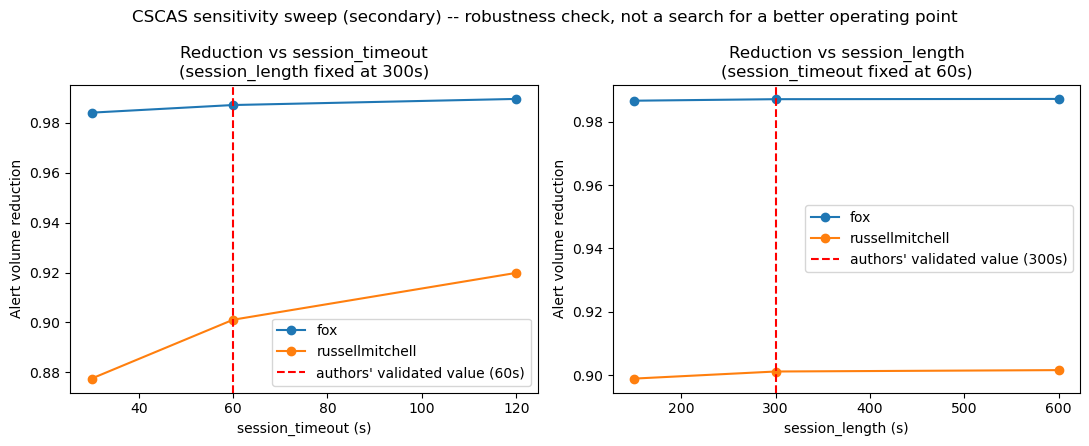

In [7]:
if cscas_sensitivity_df.empty:
    print("[skip] cscas_grouping_sensitivity not loaded -- run cscas_grouping_sensitivity.py first")
else:
    # Sensitivity diagnostic: reduction vs. each parameter, one-at-a-time,
    # with the authors' validated value marked -- a robustness check (does
    # the published config still make sense here), not a search for a
    # better operating point, so the plot deliberately doesn't highlight
    # any other point as "best."
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    timeout_df = cscas_sensitivity_df[cscas_sensitivity_df["varied"] == "session_timeout"]
    for scenario in sorted(cscas_sensitivity_df["scenario"].unique()):
        scen_df = timeout_df[timeout_df["scenario"] == scenario].sort_values("varied_value")
        axes[0].plot(scen_df["varied_value"], scen_df["reduction"], marker="o", label=scenario)
    axes[0].axvline(
        CSCAS_SESSION_TIMEOUT_SECONDS, color="red", linestyle="--",
        label=f"authors' validated value ({CSCAS_SESSION_TIMEOUT_SECONDS:g}s)",
    )
    axes[0].set_xlabel("session_timeout (s)")
    axes[0].set_ylabel("Alert volume reduction")
    axes[0].set_title(f"Reduction vs session_timeout\n(session_length fixed at {CSCAS_SESSION_LENGTH_SECONDS:g}s)")
    axes[0].legend()

    length_df = cscas_sensitivity_df[cscas_sensitivity_df["varied"] == "session_length"]
    for scenario in sorted(cscas_sensitivity_df["scenario"].unique()):
        scen_df = length_df[length_df["scenario"] == scenario].sort_values("varied_value")
        axes[1].plot(scen_df["varied_value"], scen_df["reduction"], marker="o", label=scenario)
    axes[1].axvline(
        CSCAS_SESSION_LENGTH_SECONDS, color="red", linestyle="--",
        label=f"authors' validated value ({CSCAS_SESSION_LENGTH_SECONDS:g}s)",
    )
    axes[1].set_xlabel("session_length (s)")
    axes[1].set_ylabel("Alert volume reduction")
    axes[1].set_title(f"Reduction vs session_length\n(session_timeout fixed at {CSCAS_SESSION_TIMEOUT_SECONDS:g}s)")
    axes[1].legend()

    fig.suptitle("CSCAS sensitivity sweep (secondary) -- robustness check, not a search for a better operating point")
    plt.tight_layout()
    plt.show()


## 7. AlertBERT

Delta and theta swept separately, matching the AlertBERT paper's own
asymmetric design -- see `alertbert_sweep.py`'s module docstring for the full
grid rationale, checkpoint compatibility, and GPU/conda-env requirements.
Its rows also feed directly into section 9's cross-method comparison.


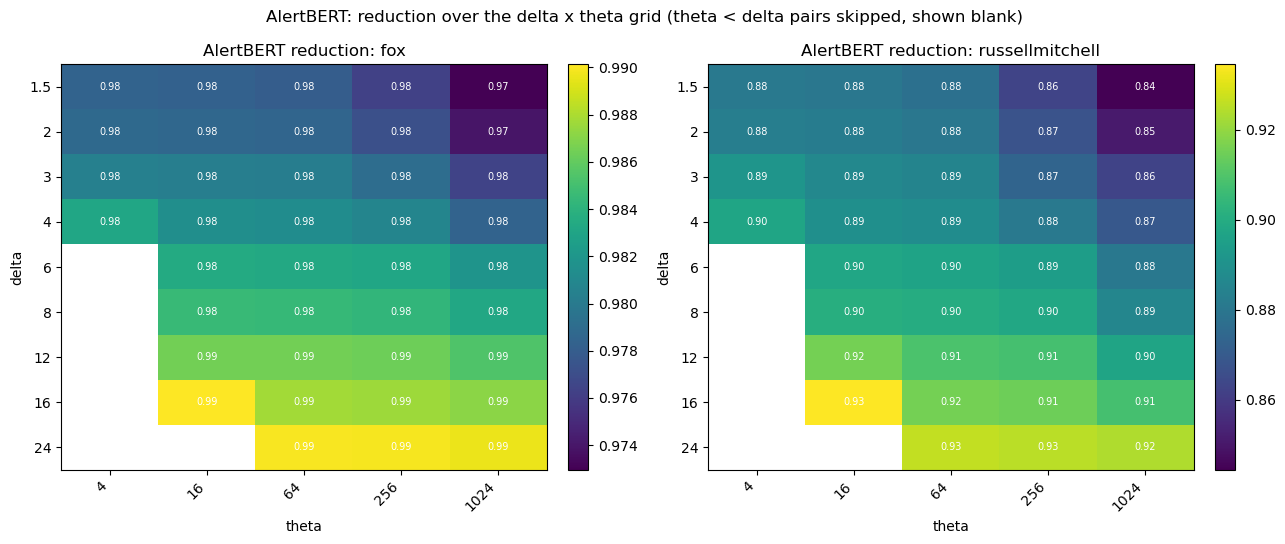

In [8]:
alertbert_df = results_dfs.get("alertbert")
if alertbert_df is None:
    print("[skip] alertbert not loaded -- run alertbert_sweep.py first")
else:
    # Diagnostic plot: reduction over the full delta x theta grid, one
    # heatmap per scenario -- a genuine 2-parameter sweep, so a heatmap
    # shows it more directly than a line plot would (contrast with the
    # CSCAS sensitivity sweep in 6b, which is deliberately one-at-a-time,
    # not a real 2D grid, so line plots were the right choice there instead).
    scenarios = sorted(alertbert_df["scenario"].unique())
    deltas = sorted(alertbert_df["delta"].unique())
    thetas = sorted(alertbert_df["theta"].unique())

    fig, axes = plt.subplots(1, len(scenarios), figsize=(6.5 * len(scenarios), 5.5), squeeze=False)
    for ax, scenario in zip(axes[0], scenarios):
        scen_df = alertbert_df[alertbert_df["scenario"] == scenario]
        pivot = scen_df.pivot(index="delta", columns="theta", values="reduction")
        pivot = pivot.reindex(index=deltas, columns=thetas)
        im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color="white")
        ax.set_xticks(range(len(thetas)))
        ax.set_xticklabels([f"{t:g}" for t in thetas], rotation=45, ha="right")
        ax.set_yticks(range(len(deltas)))
        ax.set_yticklabels([f"{d:g}" for d in deltas])
        ax.set_xlabel("theta")
        ax.set_ylabel("delta")
        ax.set_title(f"AlertBERT reduction: {scenario}")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle("AlertBERT: reduction over the delta x theta grid (theta < delta pairs skipped, shown blank)")
    plt.tight_layout()
    plt.show()


## 8. DeepCASE

Two-tier sweep (context length x DBSCAN eps) -- see `deepcase_sweep.py`'s module
docstring for the full sweep design, outlier convention, and runtime notes.


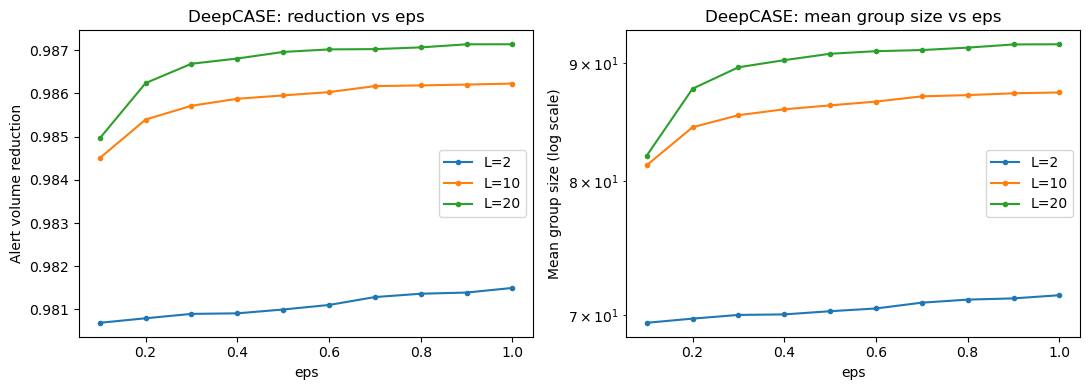

In [9]:
deepcase_df = results_dfs.get("deepcase")
if deepcase_df is None:
    print("[skip] deepcase not loaded -- run deepcase_sweep.py first")
else:
    # Per-method diagnostic plot: reduction and mean group size vs eps, one
    # line per context length L.
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    for L, group in deepcase_df.groupby("context_length"):
        agg = group.groupby("eps", as_index=False)["reduction"].mean().sort_values("eps")
        ax[0].plot(agg["eps"], agg["reduction"], marker=".", label=f"L={L}")

    ax[0].set_xlabel("eps")
    ax[0].set_ylabel("Alert volume reduction")
    ax[0].set_title("DeepCASE: reduction vs eps")
    ax[0].legend()

    for L, group in deepcase_df.groupby("context_length"):
        agg = group.groupby("eps", as_index=False)["group_size_mean"].mean().sort_values("eps")
        ax[1].plot(agg["eps"], agg["group_size_mean"], marker=".", label=f"L={L}")

    ax[1].set_yscale("log")
    ax[1].set_xlabel("eps")
    ax[1].set_ylabel("Mean group size (log scale)")
    ax[1].set_title("DeepCASE: mean group size vs eps")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


### 8b. DeepCASE manual-review queue

Each outlier alert's `reason` (`"deepcase_low_confidence"` vs
`"deepcase_dbscan_noise"`) feeds `build_manual_review_records` (inside
`deepcase_sweep.py`), which turns the rejected alerts at each (scenario,
context_length)'s default eps into the actual queue those alerts would be
routed to for analyst review, mirroring DeepCASE's own semi-automatic mode
rather than just a conceptual description.


In [10]:
manual_review_df.to_csv("grouping_manual_review_queue.csv", index=False)
print(f"Manual review queue: {len(manual_review_df)} alerts")
if not manual_review_df.empty:
    print(manual_review_df["reason"].value_counts())


Manual review queue: 104428 alerts
reason
deepcase_low_confidence    102618
deepcase_dbscan_noise        1810
Name: count, dtype: int64


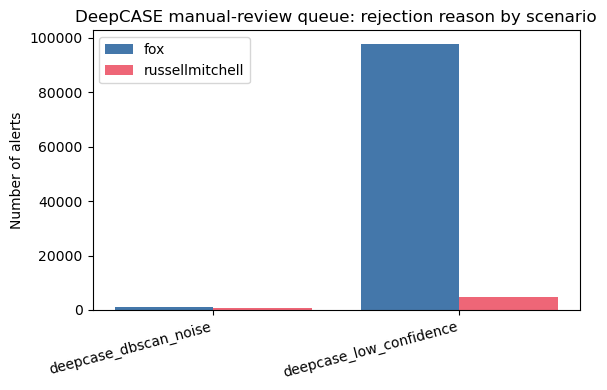

In [11]:
if manual_review_df.empty:
    print("[skip] no manual review rows loaded -- run deepcase_sweep.py first")
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    reasons = sorted(manual_review_df["reason"].unique())
    scenarios = sorted(manual_review_df["scenario"].unique())
    x = np.arange(len(reasons))
    width = 0.8 / len(scenarios)

    for i, scenario in enumerate(scenarios):
        counts = (
            manual_review_df[manual_review_df["scenario"] == scenario]["reason"]
            .value_counts()
            .reindex(reasons, fill_value=0)
        )
        ax.bar(
            x + (i - (len(scenarios) - 1) / 2) * width, counts.values, width=width,
            label=scenario, color=SCENARIO_COLORS.get(scenario),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(reasons, rotation=15, ha="right")
    ax.set_ylabel("Number of alerts")
    ax.set_title("DeepCASE manual-review queue: rejection reason by scenario")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 9. Combined results and final comparison plots

Everything loaded above, combined into one DataFrame.


In [12]:
all_results_df.to_csv("grouping_comparison_results.csv", index=False)

if all_results_df.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    summary_table = None
else:
    # Structural finding, not a trivial case: DeepCASE is the only method in
    # this comparison with a rejection/deferral path, so it should be the
    # only method with a nonzero ungroupable_fraction -- worth asserting, not
    # just omitting as an obvious zero.
    non_deepcase_ungroupable = all_results_df.loc[
        all_results_df["method"] != "deepcase", "ungroupable_fraction"
    ]
    assert (non_deepcase_ungroupable == 0.0).all(), (
        "Expected ungroupable_fraction == 0.0 for every non-DeepCASE method "
        "(none of them have a rejection step)"
    )
    print(
        "Confirmed: ungroupable_fraction is 0.0 for every non-DeepCASE method "
        "-- DeepCASE is the only method here with a rejection/deferral mode."
    )

    summary_table = all_results_df.groupby("method")[[
        "reduction", "coverage", "ungroupable_fraction", "group_size_mean", "n_groups",
        "pure_benign_frac", "pure_attack_frac", "mixed_frac",
        "host_purity", "signature_diversity_mean", "temporal_span_mean",
        "minority_label_exposure", "train_time_seconds", "inference_time_seconds",
    ]].mean()

summary_table


Confirmed: ungroupable_fraction is 0.0 for every non-DeepCASE method -- DeepCASE is the only method here with a rejection/deferral mode.


,reduction,coverage,ungroupable_fraction,group_size_mean,n_groups,pure_benign_frac,pure_attack_frac,mixed_frac,host_purity,signature_diversity_mean,temporal_span_mean,minority_label_exposure,train_time_seconds,inference_time_seconds
method,,,,,,,,,,,,,,
alertbert,0.936865,1.000000,0.000000,35.059433,6669.064103,0.934032,0.065865,0.000104,0.873958,1.416130,1.590782,0.234241,NaN,15.790034
cscas_grouping,0.944114,1.000000,0.000000,43.879518,5298.500000,0.955665,0.043809,0.000526,1.000000,1.000000,20.269532,0.409420,NaN,0.542742
deepcase,0.984541,0.947268,0.052732,82.014233,2530.700000,0.542713,0.445367,0.011921,0.979115,1.004524,5346.191414,0.015594,175.425784,NaN
fixed_window,0.942503,1.000000,0.000000,40.906919,6204.583333,0.956497,0.043382,0.000121,0.811010,1.570445,4.215183,0.073810,NaN,0.186453
fixed_window_host,0.932446,1.000000,0.000000,31.081255,7360.166667,0.952113,0.047864,0.000023,1.000000,1.463302,2.188384,0.041667,NaN,0.213730
time_delta,0.959199,1.000000,0.000000,27390.133171,4452.940476,0.856638,0.036840,0.106522,0.611501,10.154303,40474.356323,0.128821,NaN,0.368702
time_delta_host,0.950781,1.000000,0.000000,324.320653,5393.357143,0.937412,0.049216,0.013371,1.000000,2.003711,2756.918284,0.151148,NaN,0.402716


In [13]:
if all_results_df.empty:
    best_settings = pd.DataFrame()
else:
    # Best (highest-reduction) setting per method PER SCENARIO -- not
    # collapsed to a single row per method, so the plots below can show
    # both scenarios side by side instead of one silently winning. Shared
    # by the method x scenario panel and the two faceted plots after it.
    best_settings = (
        all_results_df.sort_values("reduction", ascending=False)
        .groupby(["method", "scenario"], as_index=False)
        .first()
    )
best_settings.head()


,method,scenario,param,n_raw_alerts,reduction,coverage,ungroupable_fraction,group_size_mean,group_size_median,group_size_max,...,signature_diversity_median,signature_diversity_max,temporal_span_mean,temporal_span_median,temporal_span_max,minority_label_exposure,delta,theta,context_length,eps
0,alertbert,fox,d=16.0000_t=16.0000,473104,0.990133,1.000000,0.000000,101.350471,6.0,420361,...,1.0,26,7.104113,0.0,1250.0,0.250000,16.0,16.0,NaN,NaN
1,alertbert,russellmitchell,d=16.0000_t=16.0000,45544,0.934525,1.000000,0.000000,15.272971,6.0,11248,...,1.0,25,5.501677,0.0,107.0,0.000000,16.0,16.0,NaN,NaN
2,cscas_grouping,fox,len=300_timeout=60,473104,0.987121,1.000000,0.000000,77.647136,4.0,98788,...,1.0,1,22.787953,0.0,300.0,0.500000,NaN,NaN,NaN,NaN
3,cscas_grouping,russellmitchell,len=300_timeout=60,45544,0.901107,1.000000,0.000000,10.111901,4.0,7068,...,1.0,1,17.751110,0.0,300.0,0.318841,NaN,NaN,NaN,NaN
4,deepcase,fox,L=20_eps=1.0,473104,0.992152,0.932076,0.067924,127.418260,1.0,379943,...,1.0,6,2203.157824,0.0,428704.0,0.003846,NaN,NaN,20.0,1.0


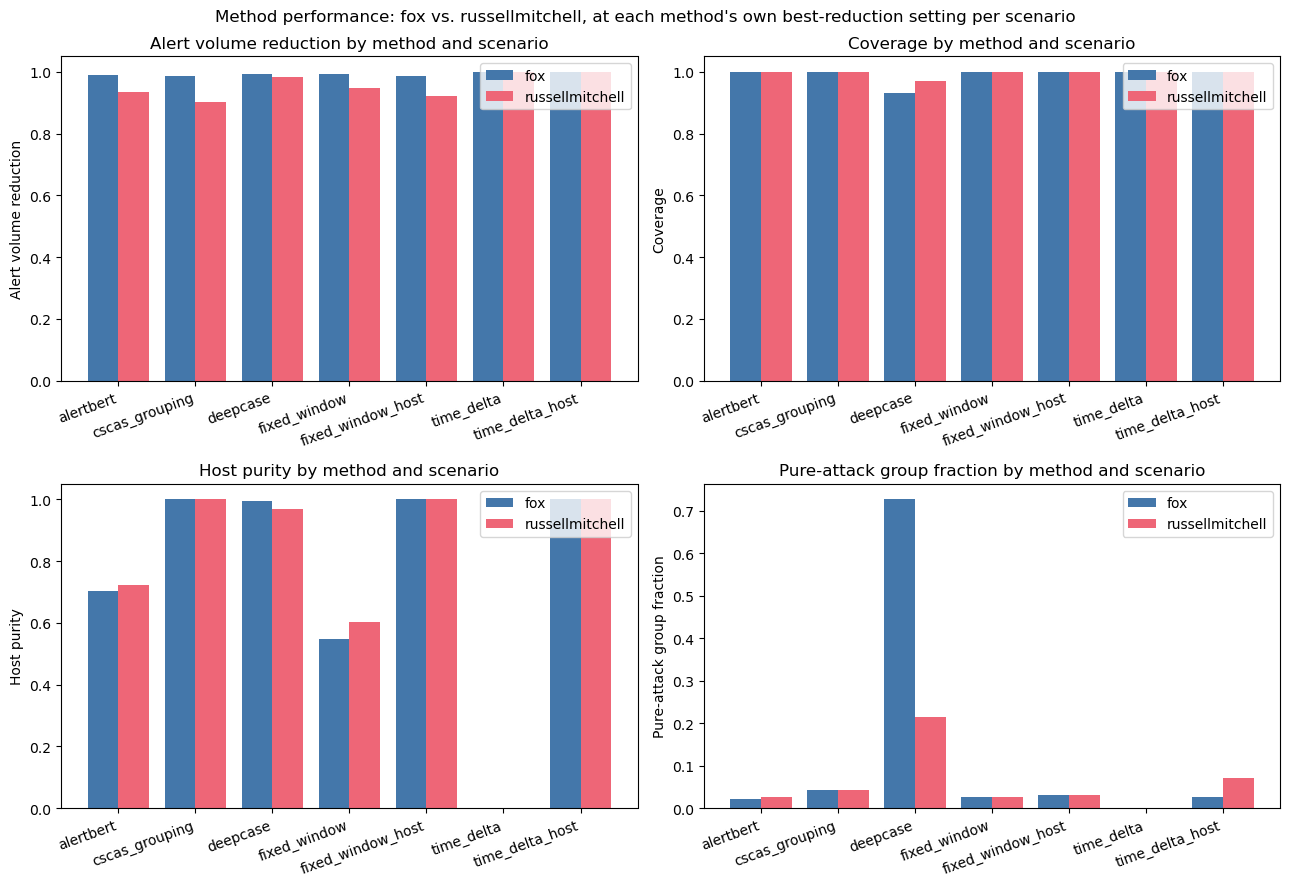

In [14]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # Headline comparison: does each method perform consistently across
    # both test scenarios, or does it diverge? One panel per metric, each a
    # grouped bar chart (method on x-axis, one bar per scenario) built from
    # each method's own best-reduction setting in that scenario.
    metrics = [
        ("reduction", "Alert volume reduction"),
        ("coverage", "Coverage"),
        ("host_purity", "Host purity"),
        ("pure_attack_frac", "Pure-attack group fraction"),
    ]
    methods = sorted(best_settings["method"].unique())
    scenarios = sorted(best_settings["scenario"].unique())
    x = np.arange(len(methods))
    width = 0.8 / len(scenarios)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for ax, (col, title) in zip(axes.flat, metrics):
        for i, scenario in enumerate(scenarios):
            scen_df = best_settings[best_settings["scenario"] == scenario].set_index("method")
            values = [scen_df[col].get(m, 0.0) for m in methods]
            ax.bar(
                x + (i - (len(scenarios) - 1) / 2) * width, values, width=width,
                label=scenario, color=SCENARIO_COLORS.get(scenario),
            )
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=20, ha="right")
        ax.set_ylabel(title)
        ax.set_title(f"{title} by method and scenario")
        ax.legend()

    fig.suptitle("Method performance: fox vs. russellmitchell, at each method's own best-reduction setting per scenario")
    plt.tight_layout()
    plt.show()


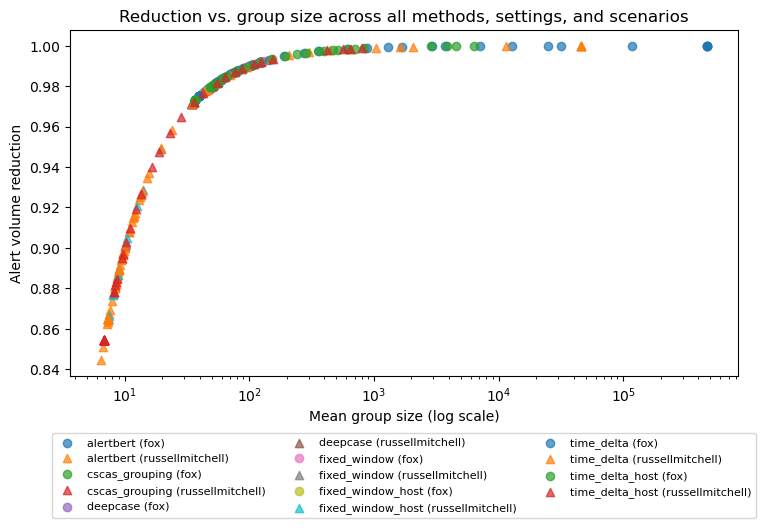

In [15]:
if all_results_df.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # Final plot 1: reduction vs mean group size, all methods overlaid,
    # split by scenario (marker shape) so a method that performs very
    # differently on fox vs russellmitchell doesn't get silently averaged
    # away. This is the key tradeoff plot -- high reduction from one giant
    # group is not the same achievement as high reduction from many
    # well-formed groups.
    fig, ax = plt.subplots(figsize=(8, 5.5))

    for (method_name, scenario), group in all_results_df.groupby(["method", "scenario"]):
        agg = group.groupby("param", as_index=False)[["reduction", "group_size_mean"]].mean()
        ax.scatter(
            agg["group_size_mean"], agg["reduction"],
            label=f"{method_name} ({scenario})",
            marker=SCENARIO_MARKERS.get(scenario, "o"),
            alpha=0.7,
        )

    ax.set_xscale("log")
    ax.set_xlabel("Mean group size (log scale)")
    ax.set_ylabel("Alert volume reduction")
    ax.set_title("Reduction vs. group size across all methods, settings, and scenarios")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()


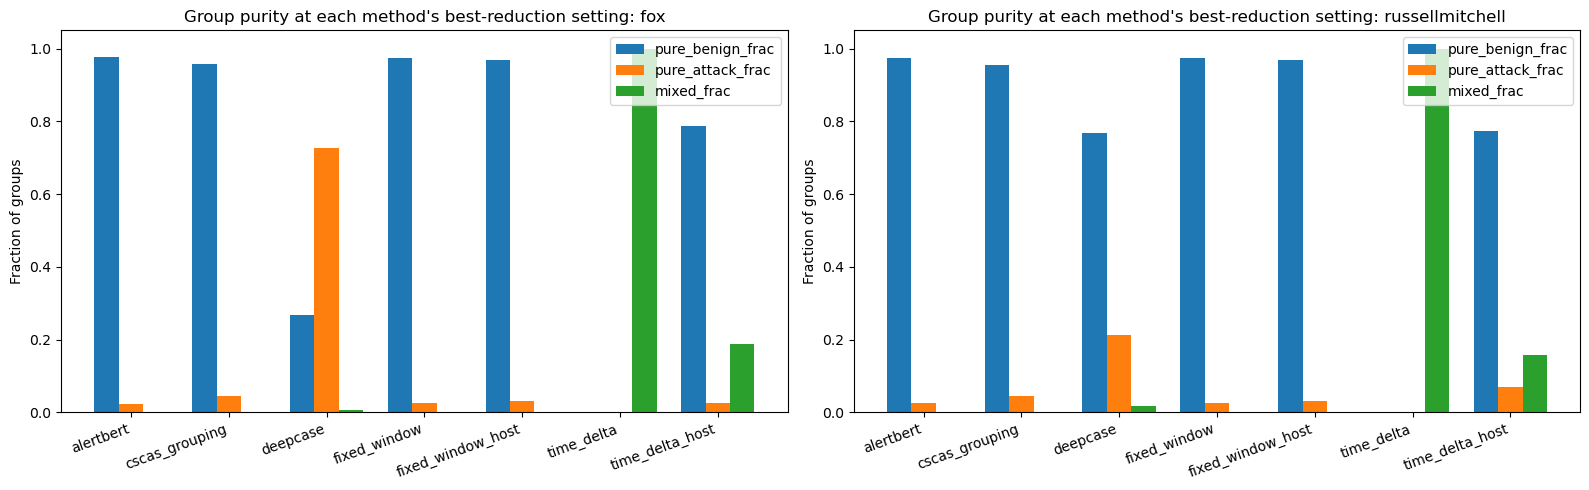

In [16]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # Final plot 2: purity comparison at each method's best-reduction
    # setting, faceted by scenario (not pooled) -- one subplot per scenario
    # so no method's bar silently reflects a different scenario than
    # another method's.
    scenarios = sorted(best_settings["scenario"].unique())
    fig, axes = plt.subplots(1, len(scenarios), figsize=(8 * len(scenarios), 5), squeeze=False)

    for ax, scenario in zip(axes[0], scenarios):
        scen_settings = best_settings[best_settings["scenario"] == scenario]
        x = np.arange(len(scen_settings))
        width = 0.25

        for i, col in enumerate(["pure_benign_frac", "pure_attack_frac", "mixed_frac"]):
            ax.bar(x + i * width, scen_settings[col], width=width, label=col)

        ax.set_xticks(x + width)
        ax.set_xticklabels(scen_settings["method"], rotation=20, ha="right")
        ax.set_ylabel("Fraction of groups")
        ax.set_title(f"Group purity at each method's best-reduction setting: {scenario}")
        ax.legend()

    plt.tight_layout()
    plt.show()


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_22006/966825611.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showfliers=True)
/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_22006/966825611.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showfliers=True)


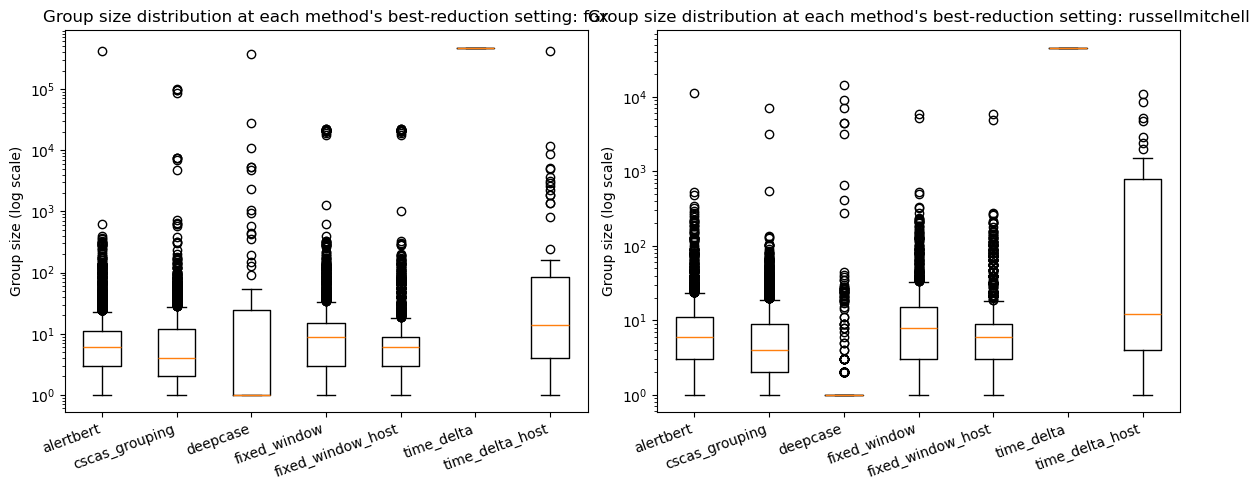

In [17]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # Final plot 3: group size distributions (log-y boxplot) at each
    # method's best-reduction setting, faceted by scenario -- surfaces the
    # runaway-group pathology (long streams of dense, repetitive alerts
    # collapsing into a single giant group) that flat mean/median stats can
    # hide. Needs the raw per-setting arrays from *_sizes.npz, not just the
    # mean/median/max already in all_results_df.
    scenarios = sorted(best_settings["scenario"].unique())
    fig, axes = plt.subplots(1, len(scenarios), figsize=(6 * len(scenarios), 5), squeeze=False)

    any_data = False
    for ax, scenario in zip(axes[0], scenarios):
        scen_settings = best_settings[best_settings["scenario"] == scenario]
        box_data = []
        labels = []
        for _, row in scen_settings.iterrows():
            key = (row["method"], row["param"], row["scenario"])
            if key in size_arrays:
                box_data.append(size_arrays[key])
                labels.append(row["method"])

        if box_data:
            any_data = True
            ax.boxplot(box_data, labels=labels, showfliers=True)
            ax.set_yscale("log")
            ax.set_ylabel("Group size (log scale)")
            ax.set_title(f"Group size distribution at each method's best-reduction setting: {scenario}")
            ax.set_xticklabels(labels, rotation=20, ha="right")
        else:
            ax.set_title(f"{scenario}: no group-size arrays loaded")

    plt.tight_layout()
    if any_data:
        plt.show()
    else:
        print("[skip] no group-size arrays loaded for any best-reduction setting")
